In [1]:
import torch

# Check if CUDA is available (meaning a GPU is detected by PyTorch)
if torch.cuda.is_available():
    # Get the number of available GPUs
    gpu_count = torch.cuda.device_count()
    print(f"Number of GPUs available: {gpu_count}")

    # Optionally, get the name of each GPU
    for i in range(gpu_count):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")
else:
    print("CUDA is not available. No GPUs detected by PyTorch.")

Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
!pip install flwr

   ---------------------------------------- 0.0/787.9 kB ? eta -:--:--
   ------------- -------------------------- 262.1/787.9 kB ? eta -:--:--
   ---------------------------------------  786.4/787.9 kB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 787.9/787.9 kB 1.5 MB/s  0:00:00
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.2 MB 2.1 MB/s eta 0:00:02
   --------- ------------------------------ 0.8/3.2 MB 1.2 MB/s eta 0:00:02
   ---------------- ----------------------- 1.3/3.2 MB 1.5 MB/s eta 0:00:02
   ------------------- -------------------- 1.6/3.2 MB 1.6 MB/s eta 0:00:02
   -------------------------- ------------- 2.1/3.2 MB 1.7 MB/s eta 0:00:01
   -------------------------- ------------- 2.1/3.2 MB 1.7 MB/s eta 0:00:01
   -------------------------------- ------- 2.6/3.2 MB 1.6 MB/s eta 0:00:01
   --------------------------

In [2]:
# fl_mnist.py
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import flwr as fl

ModuleNotFoundError: No module named 'flwr'

Starting federated simulation
Round 1/5


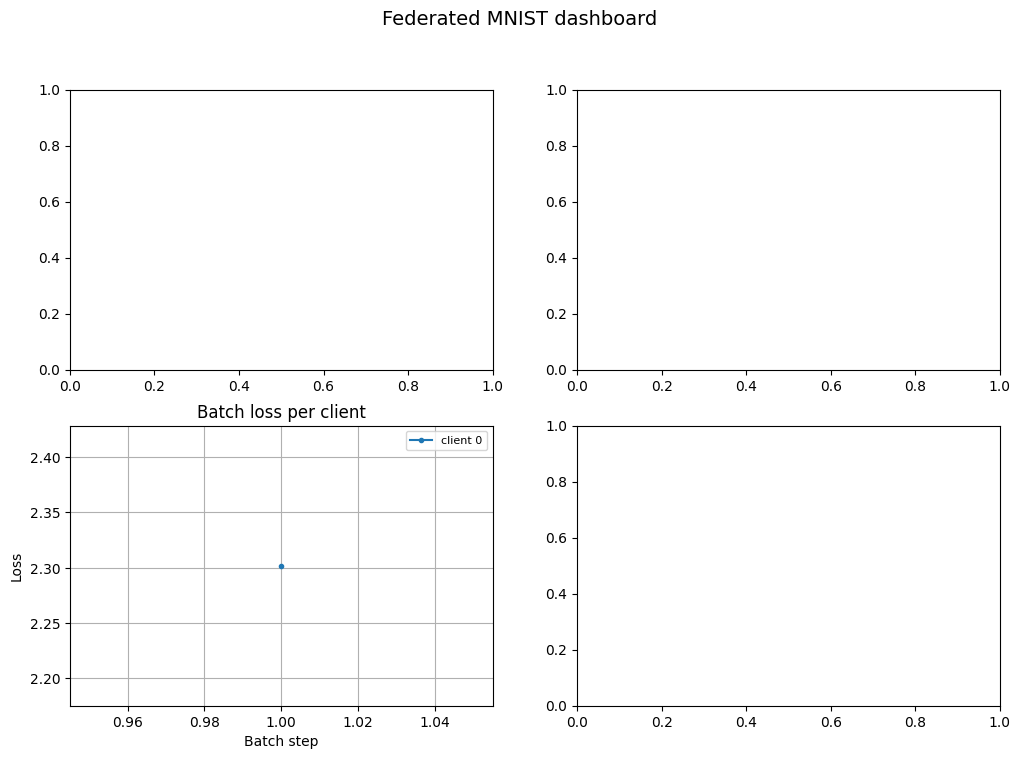

KeyboardInterrupt: 

In [9]:
"""
Federated MNIST simulation with a simple CNN in PyTorch

Dashboard layout in one window:
- Top left  : Global accuracy per round
- Top right : Global loss per round
- Bottom left  : Live batch loss for all clients
- Bottom right : Per client accuracy per round

How to run
1) Install dependencies:
   pip install torch torchvision matplotlib scikit-learn
2) Run:
   python federated_mnist_dashboard.py
"""

import os
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Simple CNN model
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # After two pools: 28 -> 14 -> 7 so feature map is 64 x 7 x 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)          # 28 -> 14
        x = F.relu(self.conv2(x))
        x = self.pool(x)          # 14 -> 7
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


def get_model():
    model = SimpleCNN().to(DEVICE)
    return model


def get_parameters(model):
    # Return a dict of numpy arrays for each parameter tensor
    return {k: v.cpu().detach().numpy() for k, v in model.state_dict().items()}


def set_parameters(model, param_dict):
    # Load parameters (numpy arrays) into model on the correct device
    state_dict = {k: torch.tensor(v).to(DEVICE) for k, v in param_dict.items()}
    model.load_state_dict(state_dict)


def average_params(param_dicts, weights):
    # param_dicts is a list of dicts mapping name to numpy array
    # weights is a list of scalars corresponding to each dict
    avg = {}
    total_weight = float(sum(weights))
    for k in param_dicts[0].keys():
        accum = None
        for p, w in zip(param_dicts, weights):
            arr = p[k].astype(np.float64)
            if accum is None:
                accum = arr * float(w)
            else:
                accum += arr * float(w)
        avg[k] = (accum / total_weight).astype(param_dicts[0][k].dtype)
    return avg


class Client:
    def __init__(self, cid, train_loader, test_loader):
        self.cid = cid
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.dataset_size = len(train_loader.dataset)

    def local_train(self, global_params, local_epochs, lr, progress_callback=None):
        model = get_model()
        set_parameters(model, global_params)
        model.train()
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        epoch_losses = []
        batch_losses = []
        global_batch_step = 0

        for epoch in range(local_epochs):
            running_loss = 0.0
            for batch_idx, (data, target) in enumerate(self.train_loader):
                data, target = data.to(DEVICE), target.to(DEVICE)
                optimizer.zero_grad()
                output = model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()

                loss_value = float(loss.item())
                running_loss += loss_value * data.size(0)
                batch_losses.append(loss_value)
                global_batch_step += 1

                if progress_callback is not None:
                    progress_callback(self.cid, global_batch_step, loss_value)

            epoch_loss = running_loss / self.dataset_size
            epoch_losses.append(epoch_loss)

        new_params = get_parameters(model)
        return new_params, epoch_losses, batch_losses

    def evaluate(self, params):
        model = get_model()
        set_parameters(model, params)
        model.eval()
        criterion = nn.CrossEntropyLoss(reduction="sum")
        loss = 0.0
        correct = 0
        preds = []
        targets = []
        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(DEVICE), target.to(DEVICE)
                output = model(data)
                loss += criterion(output, target).item()
                pred = output.argmax(dim=1)
                correct += pred.eq(target).sum().item()
                preds.append(pred.cpu().numpy())
                targets.append(target.cpu().numpy())
        loss = loss / len(self.test_loader.dataset)
        accuracy = correct / len(self.test_loader.dataset)
        preds = np.concatenate(preds)
        targets = np.concatenate(targets)
        return loss, accuracy, preds, targets


def make_dataloaders(num_clients, batch_size, non_iid=False, shards_per_client=2):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(
        root="./data", train=True, download=True, transform=transform
    )
    test_dataset = datasets.MNIST(
        root="./data", train=False, download=True, transform=transform
    )

    if not non_iid:
        # Simple uniform split
        n_train = len(train_dataset)
        base = n_train // num_clients
        lengths = [base] * num_clients
        for i in range(n_train - base * num_clients):
            lengths[i] += 1
        subsets = torch.utils.data.random_split(train_dataset, lengths)
        train_loaders = [DataLoader(s, batch_size=batch_size, shuffle=True) for s in subsets]
    else:
        # Non iid by label shards
        n_shards = num_clients * shards_per_client
        labels = np.array(train_dataset.targets)
        idxs = np.arange(len(train_dataset))
        idxs_labels = np.vstack((idxs, labels))
        idxs_labels = idxs_labels[:, idxs_labels[1, :].argsort()]
        shards = np.array_split(idxs_labels[0], n_shards)
        random.shuffle(shards)
        train_loaders = []
        for i in range(num_clients):
            client_idxs = np.concatenate(
                shards[i * shards_per_client: (i + 1) * shards_per_client]
            )
            subset = Subset(train_dataset, client_idxs.tolist())
            train_loaders.append(DataLoader(subset, batch_size=batch_size, shuffle=True))

    # For test loaders, split test dataset uniformly so each client has local test set
    n_test = len(test_dataset)
    base_test = n_test // num_clients
    lengths_test = [base_test] * num_clients
    for i in range(n_test - base_test * num_clients):
        lengths_test[i] += 1
    test_subsets = torch.utils.data.random_split(test_dataset, lengths_test)
    test_loaders = [DataLoader(s, batch_size=batch_size, shuffle=False) for s in test_subsets]

    return train_loaders, test_loaders, test_dataset


def evaluate_global_model(global_params, global_test_loader):
    model = get_model()
    set_parameters(model, global_params)
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="sum")
    loss = 0.0
    correct = 0
    preds = []
    targets = []
    with torch.no_grad():
        for data, target in global_test_loader:
            data, target = data.to(DEVICE), target.to(DEVICE)
            output = model(data)
            loss += criterion(output, target).item()
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
            preds.append(pred.cpu().numpy())
            targets.append(target.cpu().numpy())
    loss = loss / len(global_test_loader.dataset)
    accuracy = correct / len(global_test_loader.dataset)
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return loss, accuracy, preds, targets


def run_federated(
    num_clients=5,
    num_rounds=10,
    local_epochs=1,
    batch_size=32,
    lr=0.01,
    non_iid=False,
):
    train_loaders, test_loaders, global_test_dataset = make_dataloaders(
        num_clients, batch_size, non_iid=non_iid
    )
    clients = [Client(i, train_loaders[i], test_loaders[i]) for i in range(num_clients)]

    global_model = get_model()
    global_params = get_parameters(global_model)

    global_test_loader = DataLoader(global_test_dataset, batch_size=batch_size, shuffle=False)

    history = {
        "global_loss": [],
        "global_acc": [],
        "per_client_loss": defaultdict(list),
        "per_client_acc": defaultdict(list),
        "per_client_epoch_losses": defaultdict(list),
    }

    # For live plotting of batch losses
    client_batch_steps = defaultdict(list)
    client_batch_losses = defaultdict(list)

    # Dashboard figure
    plt.ion()
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    ax_global_acc = axes[0, 0]
    ax_global_loss = axes[0, 1]
    ax_batch = axes[1, 0]
    ax_client_acc = axes[1, 1]

    fig.suptitle("Federated MNIST dashboard", fontsize=14)

    def update_dashboard():
        rounds_arr = np.arange(1, len(history["global_acc"]) + 1)

        # Global accuracy
        ax_global_acc.clear()
        ax_global_acc.plot(rounds_arr, history["global_acc"], marker="o")
        ax_global_acc.set_title("Global accuracy per round")
        ax_global_acc.set_xlabel("Round")
        ax_global_acc.set_ylabel("Accuracy")
        ax_global_acc.grid(True)

        # Global loss
        ax_global_loss.clear()
        ax_global_loss.plot(rounds_arr, history["global_loss"], marker="o")
        ax_global_loss.set_title("Global loss per round")
        ax_global_loss.set_xlabel("Round")
        ax_global_loss.set_ylabel("Loss")
        ax_global_loss.grid(True)

        # Batch loss per client (all steps so far)
        ax_batch.clear()
        for cid in range(num_clients):
            steps = client_batch_steps[cid]
            losses = client_batch_losses[cid]
            if len(steps) == 0:
                continue
            ax_batch.plot(steps, losses, marker=".", linestyle="-", label=f"client {cid}")
        ax_batch.set_title("Batch loss per client")
        ax_batch.set_xlabel("Batch step")
        ax_batch.set_ylabel("Loss")
        ax_batch.grid(True)
        if len(client_batch_steps) > 0:
            ax_batch.legend(loc="upper right", fontsize=8)

        # Per client accuracy per round
        ax_client_acc.clear()
        for cid, acc_list in history["per_client_acc"].items():
            rounds_client = np.arange(1, len(acc_list) + 1)
            ax_client_acc.plot(rounds_client, acc_list, marker="o", label=f"client {cid}")
        ax_client_acc.set_title("Per client accuracy per round")
        ax_client_acc.set_xlabel("Round")
        ax_client_acc.set_ylabel("Accuracy")
        ax_client_acc.grid(True)
        if len(history["per_client_acc"]) > 0:
            ax_client_acc.legend(loc="lower right", fontsize=8)

        fig.tight_layout(rect=[0, 0.03, 1, 0.95])
        fig.canvas.draw()
        fig.canvas.flush_events()
        plt.pause(0.01)

    def progress_callback(cid, batch_step, batch_loss):
        # Store for live batch plot
        client_batch_steps[cid].append(batch_step)
        client_batch_losses[cid].append(batch_loss)

        # Limit to last 300 steps per client for faster rendering
        max_points = 300
        if len(client_batch_steps[cid]) > max_points:
            client_batch_steps[cid] = client_batch_steps[cid][-max_points:]
            client_batch_losses[cid] = client_batch_losses[cid][-max_points:]

        # Update only bottom left subplot fast
        ax_batch.clear()
        for cid_local in range(num_clients):
            steps = client_batch_steps[cid_local]
            losses = client_batch_losses[cid_local]
            if len(steps) == 0:
                continue
            ax_batch.plot(steps, losses, marker=".", linestyle="-", label=f"client {cid_local}")
        ax_batch.set_title("Batch loss per client")
        ax_batch.set_xlabel("Batch step")
        ax_batch.set_ylabel("Loss")
        ax_batch.grid(True)
        if len(client_batch_steps) > 0:
            ax_batch.legend(loc="upper right", fontsize=8)
        fig.canvas.draw()
        fig.canvas.flush_events()
        plt.pause(0.001)

    print("Starting federated simulation")
    for r in range(num_rounds):
        print(f"Round {r+1}/{num_rounds}")
        local_params_list = []
        weights = []

        for c in clients:
            new_params, epoch_losses, batch_losses = c.local_train(
                global_params,
                local_epochs,
                lr,
                progress_callback=progress_callback,
            )
            local_params_list.append(new_params)
            weights.append(c.dataset_size)

            loss_c, acc_c, _, _ = c.evaluate(new_params)
            history["per_client_loss"][c.cid].append(loss_c)
            history["per_client_acc"][c.cid].append(acc_c)
            history["per_client_epoch_losses"][c.cid].append(epoch_losses)

        # Aggregate
        aggregated = average_params(local_params_list, weights)
        global_params = aggregated

        # Evaluate global model
        gl_loss, gl_acc, gl_preds, gl_targets = evaluate_global_model(
            global_params, global_test_loader
        )
        history["global_loss"].append(gl_loss)
        history["global_acc"].append(gl_acc)

        update_dashboard()

        print(f" Global test loss: {gl_loss:.4f}  Global test acc: {gl_acc:.4f}")

    # Final evaluation
    final_loss, final_acc, final_preds, final_targets = evaluate_global_model(
        global_params, global_test_loader
    )
    print("\nFinal global model evaluation")
    print(f" Loss: {final_loss:.4f}  Accuracy: {final_acc:.4f}")

    results = {
        "global_params": global_params,
        "history": history,
        "final_preds": final_preds,
        "final_targets": final_targets,
    }
    return results


def plot_results(results, out_dir="plots"):
    os.makedirs(out_dir, exist_ok=True)
    history = results["history"]
    num_rounds = len(history["global_acc"]) if len(history["global_acc"]) > 0 else 0
    rounds = np.arange(1, num_rounds + 1)

    plt.ioff()

    # Global accuracy
    plt.figure()
    plt.plot(rounds, history["global_acc"], marker="o")
    plt.title("Global Test Accuracy per Round")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, "global_accuracy.png"))
    plt.close()

    # Global loss
    plt.figure()
    plt.plot(rounds, history["global_loss"], marker="o")
    plt.title("Global Test Loss per Round")
    plt.xlabel("Round")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.savefig(os.path.join(out_dir, "global_loss.png"))
    plt.close()

    # Per client accuracy
    plt.figure(figsize=(8, 5))
    for cid, acc_list in history["per_client_acc"].items():
        rounds_client = np.arange(1, len(acc_list) + 1)
        plt.plot(rounds_client, acc_list, marker="o", label=f"client {cid}")
    plt.title("Per Client Accuracy per Round")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    if len(history["per_client_acc"]) > 0:
        plt.legend()
    plt.savefig(os.path.join(out_dir, "per_client_accuracy.png"))
    plt.close()

    # Confusion matrix
    preds = results["final_preds"]
    targets = results["final_targets"]
    cm = confusion_matrix(targets, preds)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix - Final Global Model")
    plt.colorbar()
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.savefig(os.path.join(out_dir, "confusion_matrix.png"))
    plt.close()

    # Class wise accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)
    plt.figure(figsize=(8, 5))
    plt.bar(np.arange(len(class_acc)), class_acc)
    plt.title("Class Wise Accuracy - Final Global Model")
    plt.xlabel("Class")
    plt.ylabel("Accuracy")
    plt.xticks(np.arange(len(class_acc)))
    plt.grid(axis="y")
    plt.savefig(os.path.join(out_dir, "class_accuracy.png"))
    plt.close()


if __name__ == "__main__":
    NUM_CLIENTS = 5
    NUM_ROUNDS = 5
    LOCAL_EPOCHS = 1
    BATCH_SIZE = 64
    LR = 0.01
    NON_IID = False

    results = run_federated(
        num_clients=NUM_CLIENTS,
        num_rounds=NUM_ROUNDS,
        local_epochs=LOCAL_EPOCHS,
        batch_size=BATCH_SIZE,
        lr=LR,
        non_iid=NON_IID,
    )
    plot_results(results)

    print("Plots saved in folder plots.")
